## **Heart Disease Prediction**







### Problem Statement
Heart disease is easier to treat when it is detected in the early stages. Machine learning techniques may aid a more efficient analysis in the prediction of the disease. Moreover, this prediction is one of the most central problems in medical, as it is one of the leading disease related to unhealthy lifestyle. So, an early prediction of this disease will be useful for a cure or averion. In this study, we experiment with the heart disease dataset to explore the machine learning algorithms and build an optimum model to predict the disease.

### Data Definition
Each attribute is a medical risk factor.

age: Age of the patient - (Numerical)

gender: Gender of the patient - (0,1) - (Male, Female) - (Categorical)

chest_pain: It refers to the chest pain experienced by the patient -(0,1,2,3) - (Categorical)

rest_bps: Blood pressure of the patient while resting(in mm/Hg) - (Numerical)

cholestrol: Patient's cholestrol level (in mg/dl) - (Numerical)

fasting_blood_sugar: Blood sugar of the patient while fasting - (>120mg/: = 1, otherwise = 0) - (Categorical)

rest_ecg: Potassium level (0,1,2) - (Categorical)

thalach: The patients maximum heart rate - (Numerical)

exer_angina: It refers to the exercise induced angina - (1=Yes, 0=No) - (Categorical)

old_peak: It is the ST depression induced by exercise relative to rest(ST relates to the position on ECG plots) (Numerical)

slope: It refers to the slope of the peak of the exercise ST Segment- (0,1,2) - (Categorical)

ca: Number of major vessels - (0,1,2,3,4) - (Categorical)

thalassemia: It refers to thalassemia which is a blood disorder - (0,1,2,3) - (Categorical)

target: Patient has heart disease or not - (1=Yes, 0=No) - (Target variable)

### 1. Import Libraries

In [16]:
# suppress display of warnings
import warnings
warnings.filterwarnings("ignore")

import os

# 'Pandas' is used for data manipulation and analysis
import pandas as pd 

# 'Numpy' is used for mathematical operations on large, multi-dimensional arrays and matrices
import numpy as np

# 'Matplotlib' is a data visualization library for 2D and 3D plots, built on numpy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 'Seaborn' is based on matplotlib; used for plotting statistical graphics
import seaborn as sns

# import 'is_string_dtype' to check if the type of input is string  
from pandas.api.types import is_string_dtype

# import various functions to perform classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
#from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.tree import export_graphviz
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.ensemble import AdaBoostClassifier
#from sklearn.ensemble import GradientBoostingClassifier

# import functions to perform logistic regression
import statsmodels
import statsmodels.api as sm

# import functions to plot the decision tree
import pydotplus
from IPython.display import Image  
import graphviz

### 2. Set Option

In [ ]:
# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None

# use below code to convert the 'exponential' values to float
np.set_printoptions(suppress=True)

### 3. Read Data

In [5]:
# read the excel data file 
import pandas as pd
df_Heart = pd.read_csv("HeartDisease.csv")

# display the top 5 rows of the dataframe
df_Heart.head()

# Note: To display more rows, example 10, use head(10)

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#### Dimensions of the data

In [6]:
# 'shape' function gives the total number of rows and columns in the data
df_Heart.shape

(303, 14)

### 4. Data Analysis & Preparation

##### 4.1 Datatype
The main data types in Pandas dataframes are the object, float, int64, bool, and datetime64. To understand each attribute of our data, it is always good for us to know the data type of each column.



In [ ]:
# 'dtypes' gives the data type for each column
df_Heart.dtypes

age                      int64
gender                   int64
chest_pain               int64
rest_bps                 int64
cholestrol               int64
fasting_blood_sugar      int64
rest_ecg                 int64
thalach                  int64
exer_angina              int64
old_peak               float64
slope                    int64
ca                       int64
thalassemia              int64
target                   int64
dtype: object

In [7]:
# splitting features and the target variable
# consider all the columns except 'target' using 'iloc'
df_features = df_Heart.iloc[:, df_Heart.columns != 'target']

# consider the target variable
df_target = df_Heart.iloc[:,df_Heart.columns == 'target']

In [ ]:
# the describe() returns the statistical summary of the variables
# by default, it returns the summary of numerical variables
#We transpose the results for better readability
df_features.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
gender,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
chest_pain,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
rest_bps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
cholestrol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fasting_blood_sugar,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
rest_ecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exer_angina,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
old_peak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


#### Missing values 

In [ ]:
# sort the variables on the basis of total null values in the variable
# 'isnull().sum()' returns the number of missing values in each variable
# 'ascending = False' sorts values in the descending order
# the variable with highest number of missing values will appear first
Total = df_Heart.isnull().sum().sort_values(ascending = False)          

# calculate the percentage of missing values
# 'ascending = False' sorts values in the descending order
# the variable with highest percentage of missing values will appear first
Percent = (df_Heart.isnull().sum()*100/df_Heart.isnull().count()).sort_values(ascending = False)   

# concat the 'Total' and 'Percent' columns using 'concat' function
# 'keys' is the list of column names
# 'axis = 1' concats along the columns
missing_data = pd.concat([Total, Percent], axis = 1, keys = ['Total', 'Percentage of Missing Values'])    
missing_data

,Total,Percentage of Missing Values
age,0,0.0
gender,0,0.0
chest_pain,0,0.0
rest_bps,0,0.0
cholestrol,0,0.0
fasting_blood_sugar,0,0.0
rest_ecg,0,0.0
thalach,0,0.0
exer_angina,0,0.0
old_peak,0,0.0


Another way to find the missing values is to plot a heatmap for visualization.



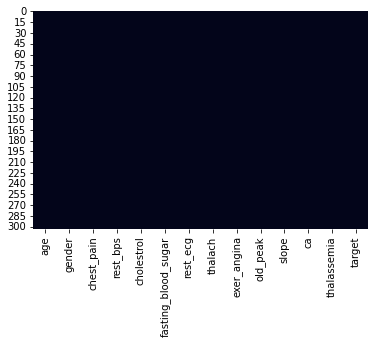

In [ ]:
# plot heatmap to check null values
# 'cbar = False' does not show the color axis 
sns.heatmap(df_Heart.isnull(), cbar=False)

# display the plot
plt.show()

There are no horizontal lines in the heatmap which would correspond to a probable missing values.

In [ ]:
#To check if there are any special characters in place of values 
for i in df_Heart.columns:
    print({i:df_Heart[i].unique()})

{'age': array([63, 37, 41, 56, 57, 44, 52, 54, 48, 49, 64, 58, 50, 66, 43, 69, 59,
       42, 61, 40, 71, 51, 65, 53, 46, 45, 39, 47, 62, 34, 35, 29, 55, 60,
       67, 68, 74, 76, 70, 38, 77])}
{'gender': array([1, 0])}
{'chest_pain': array([3, 2, 1, 0])}
{'rest_bps': array([145, 130, 120, 140, 172, 150, 110, 135, 160, 105, 125, 142, 155,
       104, 138, 128, 108, 134, 122, 115, 118, 100, 124,  94, 112, 102,
       152, 101, 132, 148, 178, 129, 180, 136, 126, 106, 156, 170, 146,
       117, 200, 165, 174, 192, 144, 123, 154, 114, 164])}
{'cholestrol': array([233, 250, 204, 236, 354, 192, 294, 263, 199, 168, 239, 275, 266,
       211, 283, 219, 340, 226, 247, 234, 243, 302, 212, 175, 417, 197,
       198, 177, 273, 213, 304, 232, 269, 360, 308, 245, 208, 264, 321,
       325, 235, 257, 216, 256, 231, 141, 252, 201, 222, 260, 182, 303,
       265, 309, 186, 203, 183, 220, 209, 258, 227, 261, 221, 205, 240,
       318, 298, 564, 277, 214, 248, 255, 207, 223, 288, 160, 394, 315,
       2

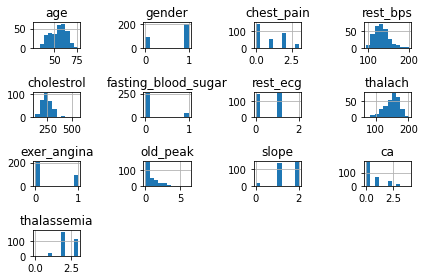

In [ ]:
# plot the histogram of numeric independent variables
# the hist() function considers the numeric variables only, by default
df_features.hist()

# adjust the subplots
plt.tight_layout()

# display the plot
plt.show()

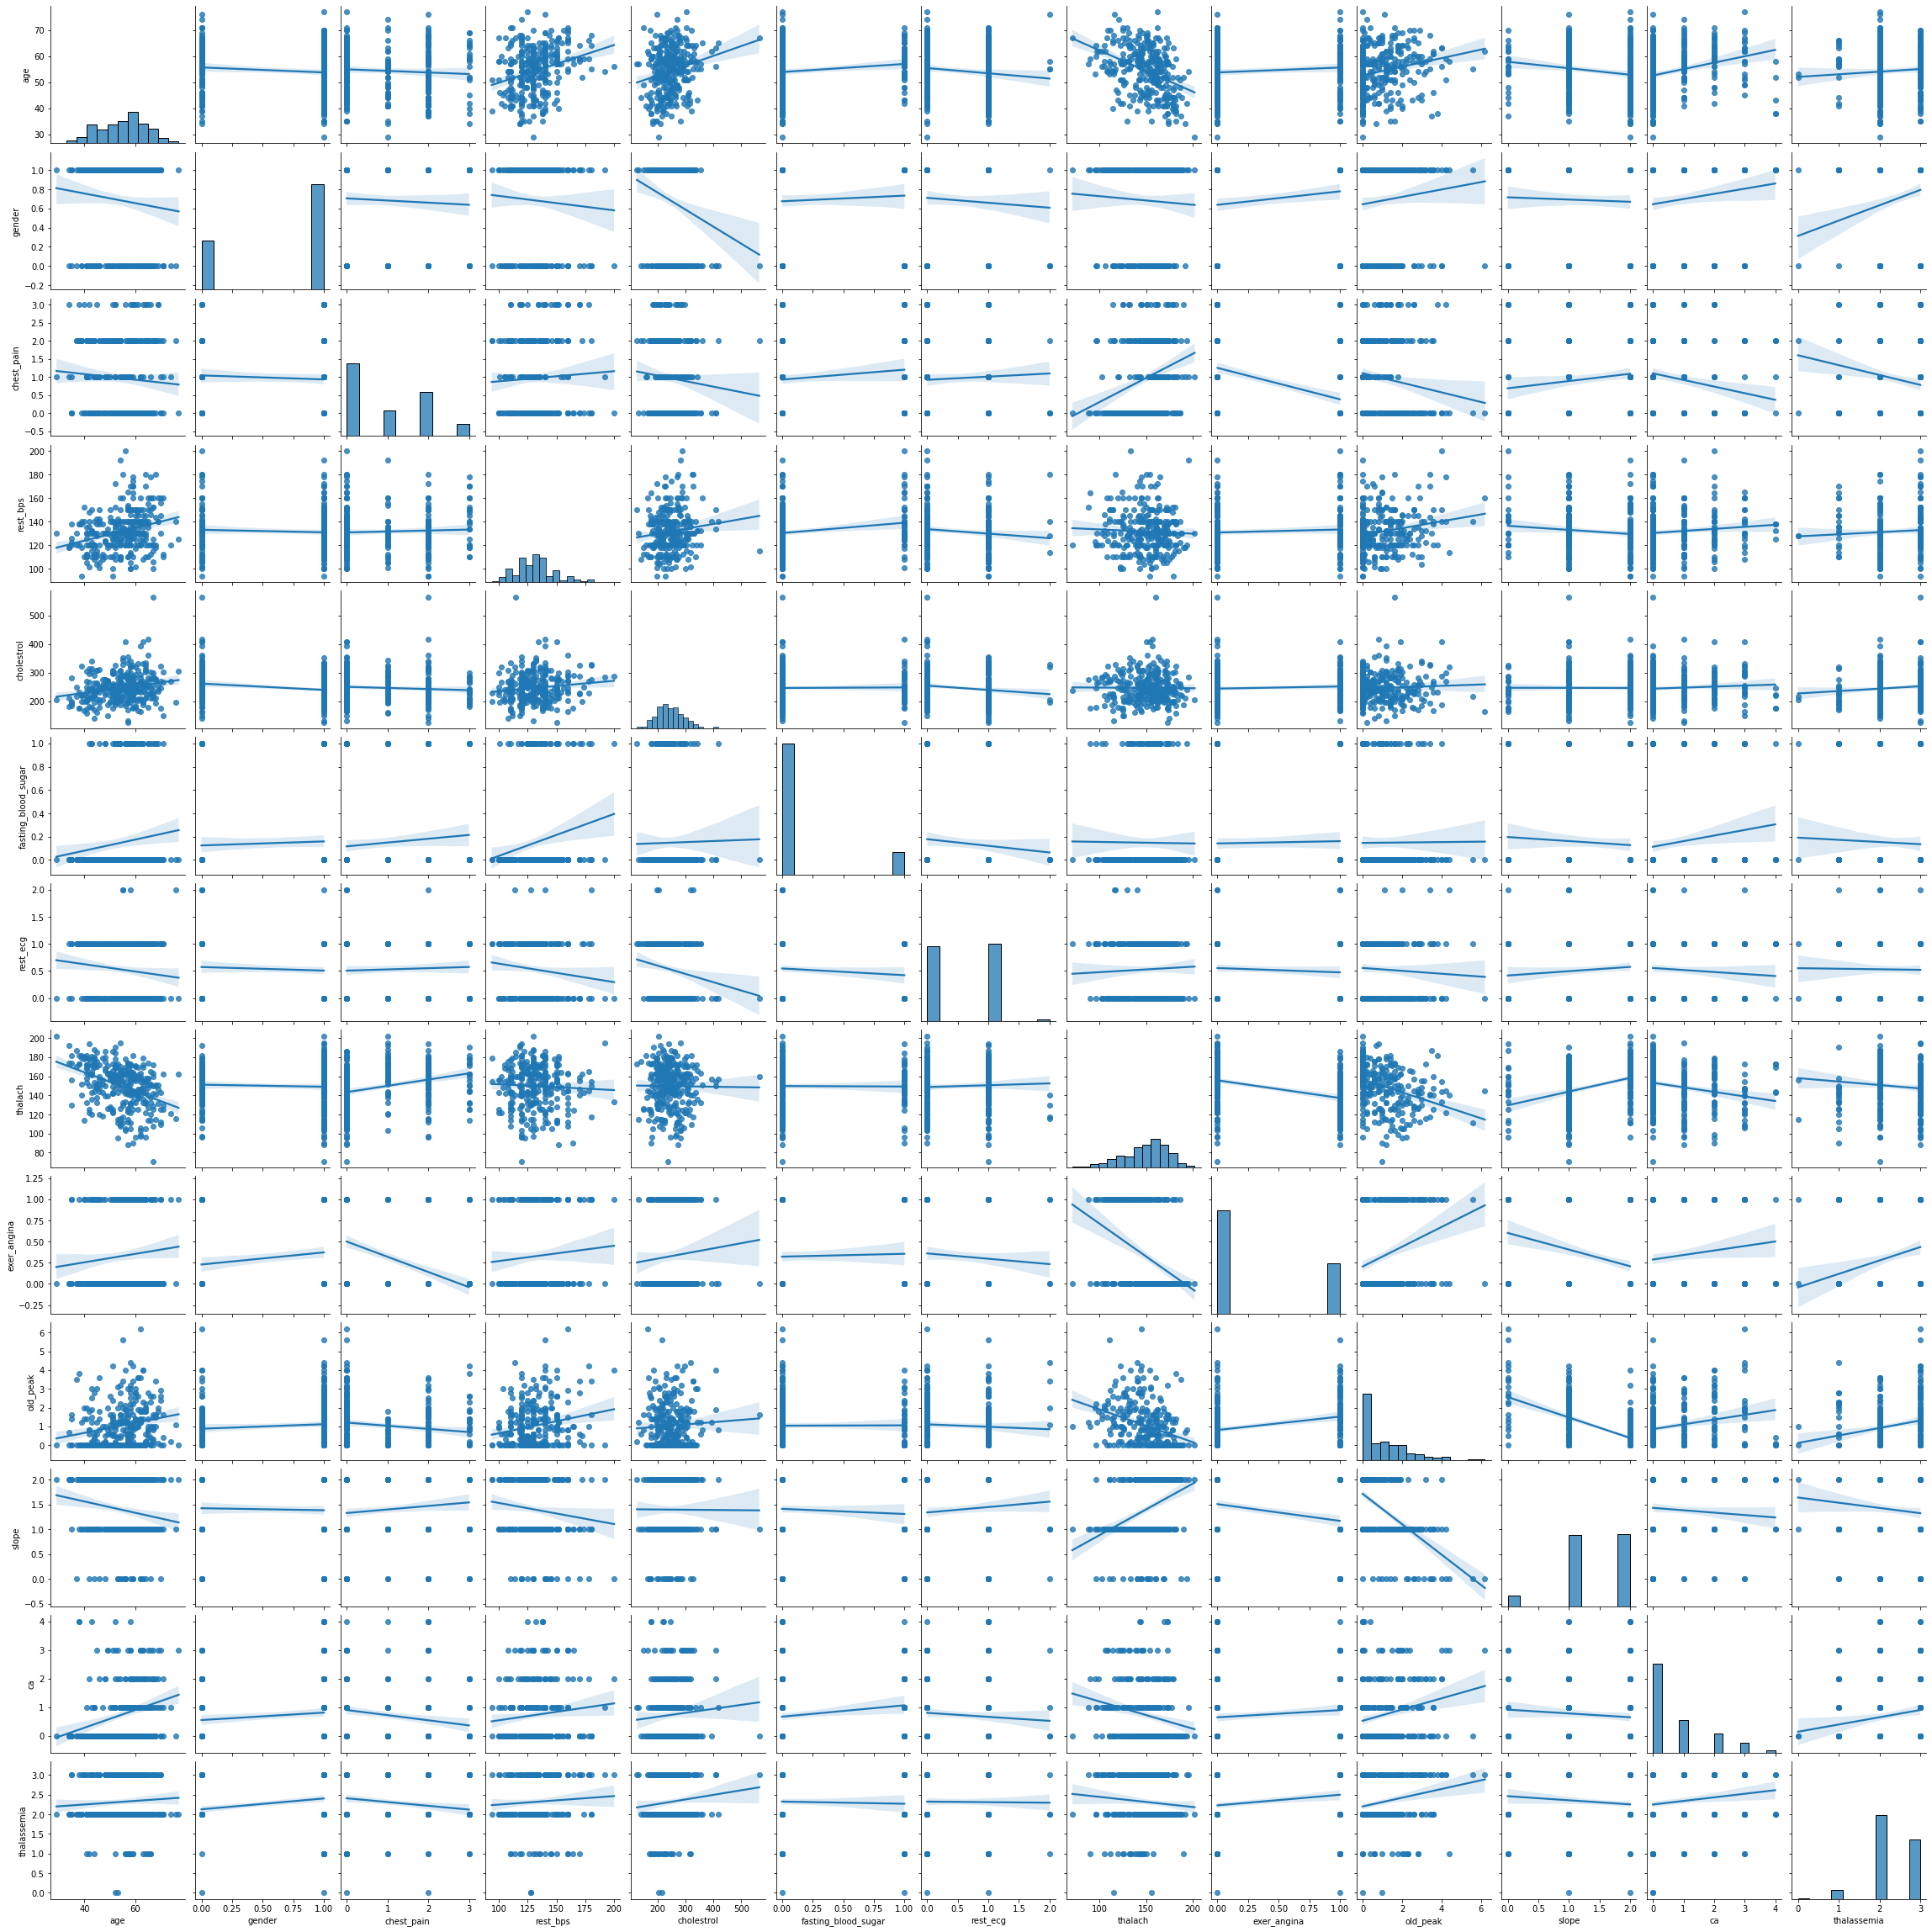

In [ ]:
#Basic Correlogram
sns.pairplot(df_features,kind="reg")
plt.show()

In [8]:
# get counts of 0's and 1's in the 'target' variable using 'value_counts()'
# store the values in 'class_frequency'
class_frequency = df_target.target.value_counts()
class_frequency

1    165
0    138
Name: target, dtype: int64

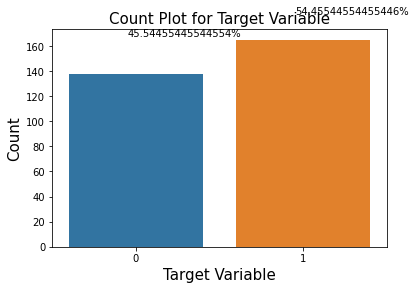

In [ ]:
# plot the countplot of the variable 'target'
sns.countplot(x = df_target.target)

# use below code to print the values in the graph
# 'x' and 'y' gives position of the text
# 's' is the text on the plot
plt.text(x = -0.05, y = df_target.target.value_counts()[0] + 30, s = str((class_frequency[0])*100/len(df_target.target)) + '%')
plt.text(x = 0.95, y = df_target.target.value_counts()[1] +20, s = str((class_frequency[1])*100/len(df_target.target)) + '%')

# add plot and axes labels
# set text size using 'fontsize'
plt.title('Count Plot for Target Variable', fontsize = 15)
plt.xlabel('Target Variable', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

# to show the plot
plt.show()

##### Correlation

Correlation is a statistic that measures the degree to which two variables move with each other. A correlation coefficient near 1 indicates the strong relationship between them; a weak correlation indicates the extent to which one variable increases as the other decreases. Correlation among multiple variables can be represented in the form of a matrix. This allows us to see which variables are correlated.



In [ ]:
# use the corr() function to generate the correlation matrix of the numeric variables
corr = df_features.corr()

# print the correlation matrix
corr

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001
gender,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041
chest_pain,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736
rest_bps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210
cholestrol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803
fasting_blood_sugar,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019
rest_ecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439
exer_angina,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754
old_peak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244


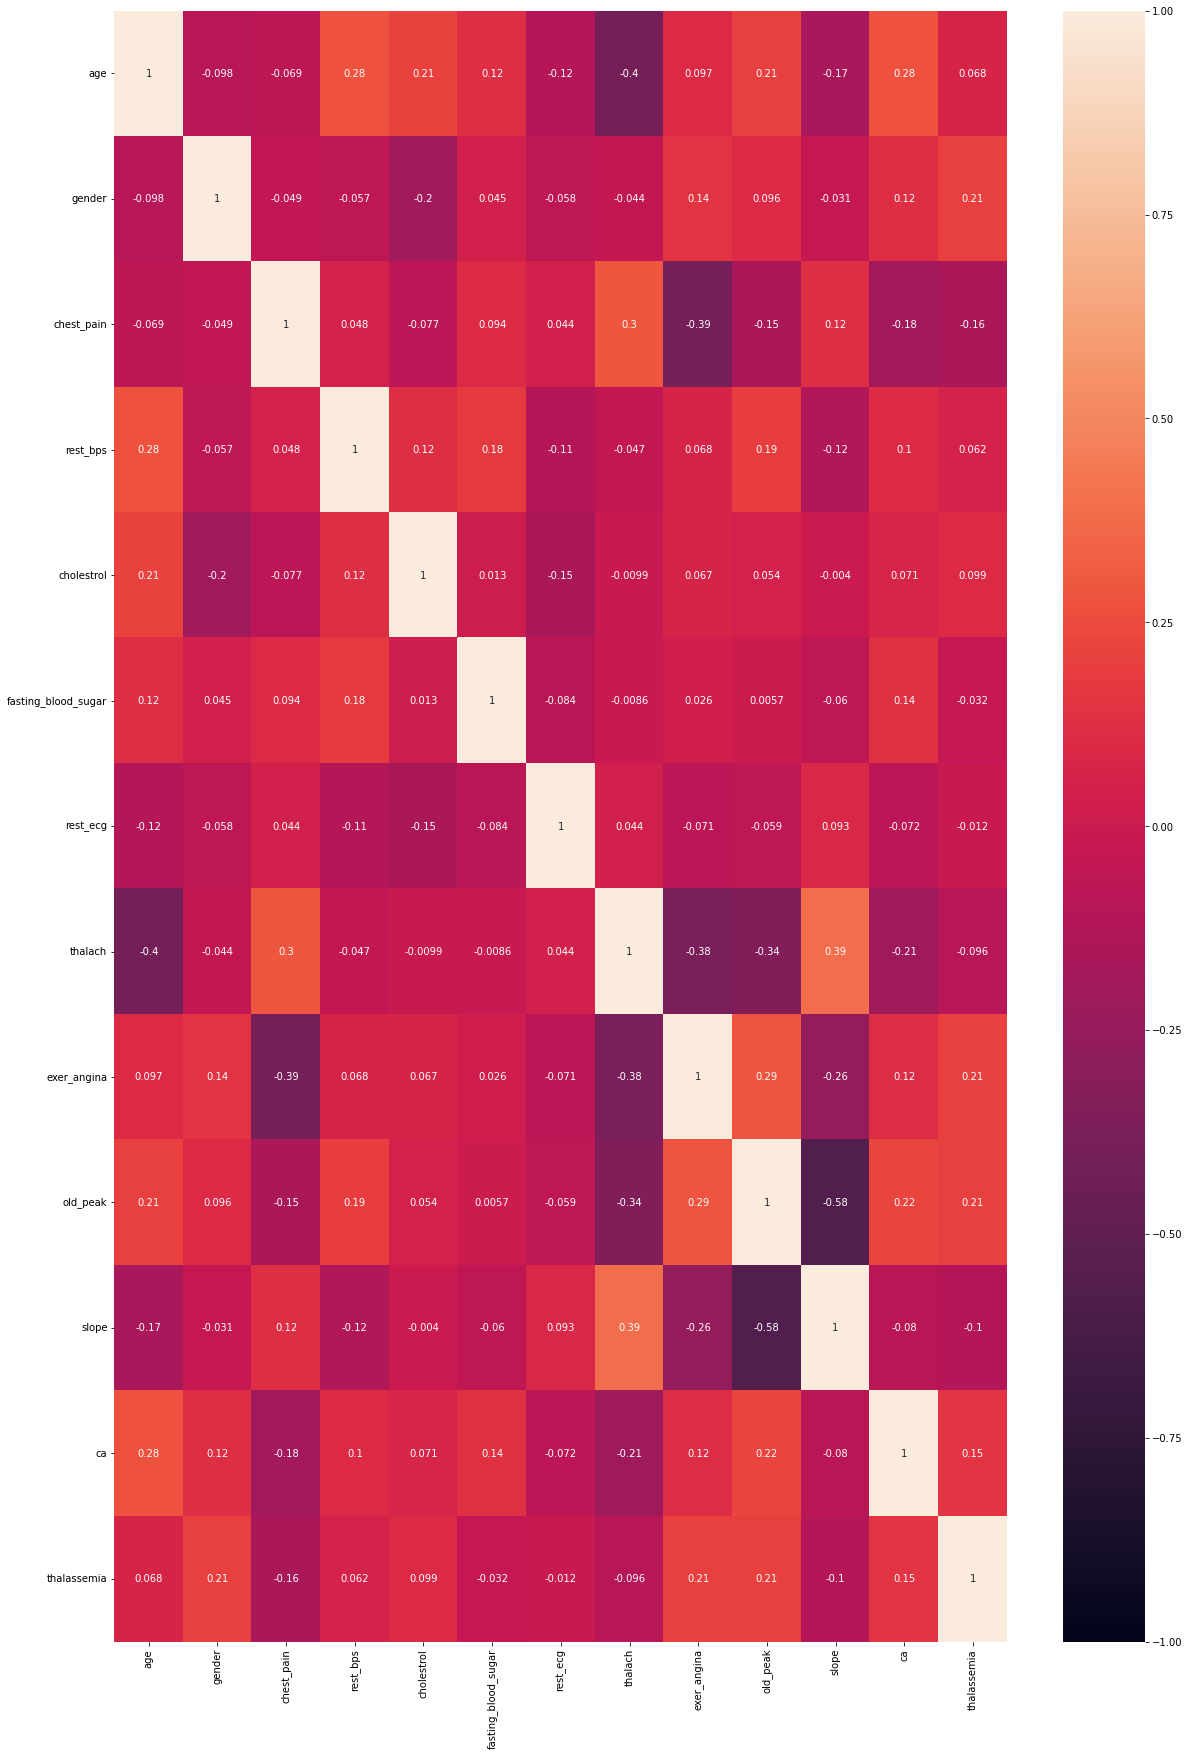

In [ ]:

plt.figure(figsize=(20,30))
sns.heatmap(corr, vmin=-1.0,vmax=1.0,annot=True)
plt.yticks(rotation=0)
plt.show()

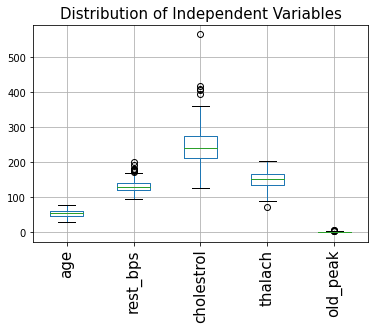

In [ ]:
# make a list of numerical features without considering the 'white corpuscle'
cols = ['age','rest_bps','cholestrol','thalach','old_peak']

# plot multiple boxplots
df_Heart[cols].boxplot()

# set plot label
# set text size using 'fontsize'
plt.title('Distribution of Independent Variables', fontsize = 15)

# xticks() returns the x-axis ticks
# 'rotation = vertical' rotates the x-axis labels vertically
plt.xticks(rotation = 'vertical', fontsize = 15)

# display the plot
plt.show()

**Notice that the variables 'age' , 'old_peak' has a quite small range as compared to the other variables. Thus, it is difficult to see the outliers for these variables. So, we plot the boxplot only for the variables 'age', 'old_peak'.**

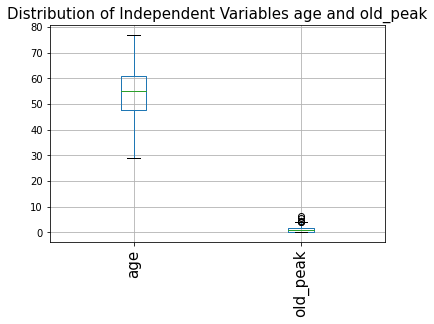

In [ ]:
# make a list of numerical features 
cols = [ 'age','old_peak']

# plot multiple boxplots
df_features[cols].boxplot()

# set plot label
# set text size using 'fontsize'
plt.title('Distribution of Independent Variables age and old_peak', fontsize = 15)

# xticks() returns the x-axis ticks
# 'rotation = vertical' rotates the x-axis labels vertically
plt.xticks(rotation = 'vertical', fontsize = 15)

# display the plot
plt.show()

In [ ]:
# calculate the first quartile
Q1 = df_features.quantile(0.25)

# calculate the third quartile
Q3 = df_features.quantile(0.75)

# Interquartile Range (IQR) is defined as the difference between the third and first quartile
# calculate IQR
IQR = Q3 - Q1

# print the IQR
print(IQR)

age                    13.5
gender                  1.0
chest_pain              2.0
rest_bps               20.0
cholestrol             63.5
fasting_blood_sugar     0.0
rest_ecg                1.0
thalach                32.5
exer_angina             1.0
old_peak                1.6
slope                   1.0
ca                      1.0
thalassemia             1.0
dtype: float64


## 5. Data Preparation:
Before proceeding towards model building the data is splitting X & Y , then  into training & testing part.
### Creating X & Y

In [9]:
X = df_Heart.iloc[:,0:-1]
Y = df_Heart.iloc[:,-1]

In [10]:
X = pd.DataFrame(X)


### Scaling the data
As there are different feature variables in X, it can have a possibility of giving more importance to the variables having greater range and give less important to variables having small range which is not suitable. So to overcome this problem scaling is done on the all variables in X, as it will bring all the variables in a same range

In [11]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

scaler.fit(X)
X = scaler.transform(X)

## 6. Decision Tree

Decision Tree is a non-parametric supervised learning method. It builds a regression model in the form of a tree structure. It breaks down a data set into smaller and smaller subsets, which is called splitting. The final result is a tree with a decision and leaf nodes. A decision node has two or more branches. The leaf node represents a class or decision. The topmost decision node in a tree that corresponds to the best predictor called 'root node'. The decision tree is built using different criteria like gini index, and entropy.

To build a Decision Tree, we do the following:

1. Split the data into training and test sets
2. Build the model
3. Plot the decision tree
4. Do predictions on the test set
5. Compute accuracy measures
6. Tabulate the results

#### Train-Test Split

In [12]:
# split data into train subset and test subset
# set 'random_state' to generate the same dataset each time you run the code 
# 'test_size' returns the proportion of data to be included in the test set
from sklearn.model_selection import train_test_split  #<1000=in range of 80-20  &  >1000=in range of 70-30

#Split the data into test and train
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=10)

In [13]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(212, 13)
(212,)
(91, 13)
(91,)


#### Build the model

In [20]:
# instantiate the 'DecisionTreeClassifier' object using 'entropy' criterion
# pass the 'random_state' to obtain the same samples for each time you run the code
decision_tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 10)

# fit the model using fit() on train data
decision_tree_model = decision_tree.fit(X_train, Y_train)

In [22]:
print(list(zip(df_Heart.columns[:-1],decision_tree.feature_importances_)))

[('age', 0.1066000232627749), ('gender', 0.04891938003228758), ('chest_pain', 0.26815962028673285), ('rest_bps', 0.1293262826553781), ('cholestrol', 0.1114596985258445), ('fasting_blood_sugar', 0.0), ('rest_ecg', 0.01927071785140945), ('thalach', 0.0681846618743239), ('exer_angina', 0.029387196601510613), ('old_peak', 0.03552523074616944), ('slope', 0.056242944596791127), ('ca', 0.1269242435667775), ('thalassemia', 0.0)]


Although we see that fasting_blood_sugar and thalassemia show a value of 0 in the importances, we know that they are very much related to the heart disease. So we will not eliminate them and go forward to tune the model keeping all the variables.

In [ ]:
from sklearn import tree
with open(r"model_DecisionTree.txt", "w") as f:
    
    f = tree.export_graphviz(decision_tree_model, feature_names=df_Heart.columns[0:-1],
                             out_file=f)
    
#generate the file and upload the code in webgraphviz.com to plot the decision tree

#### Plot the decision tree

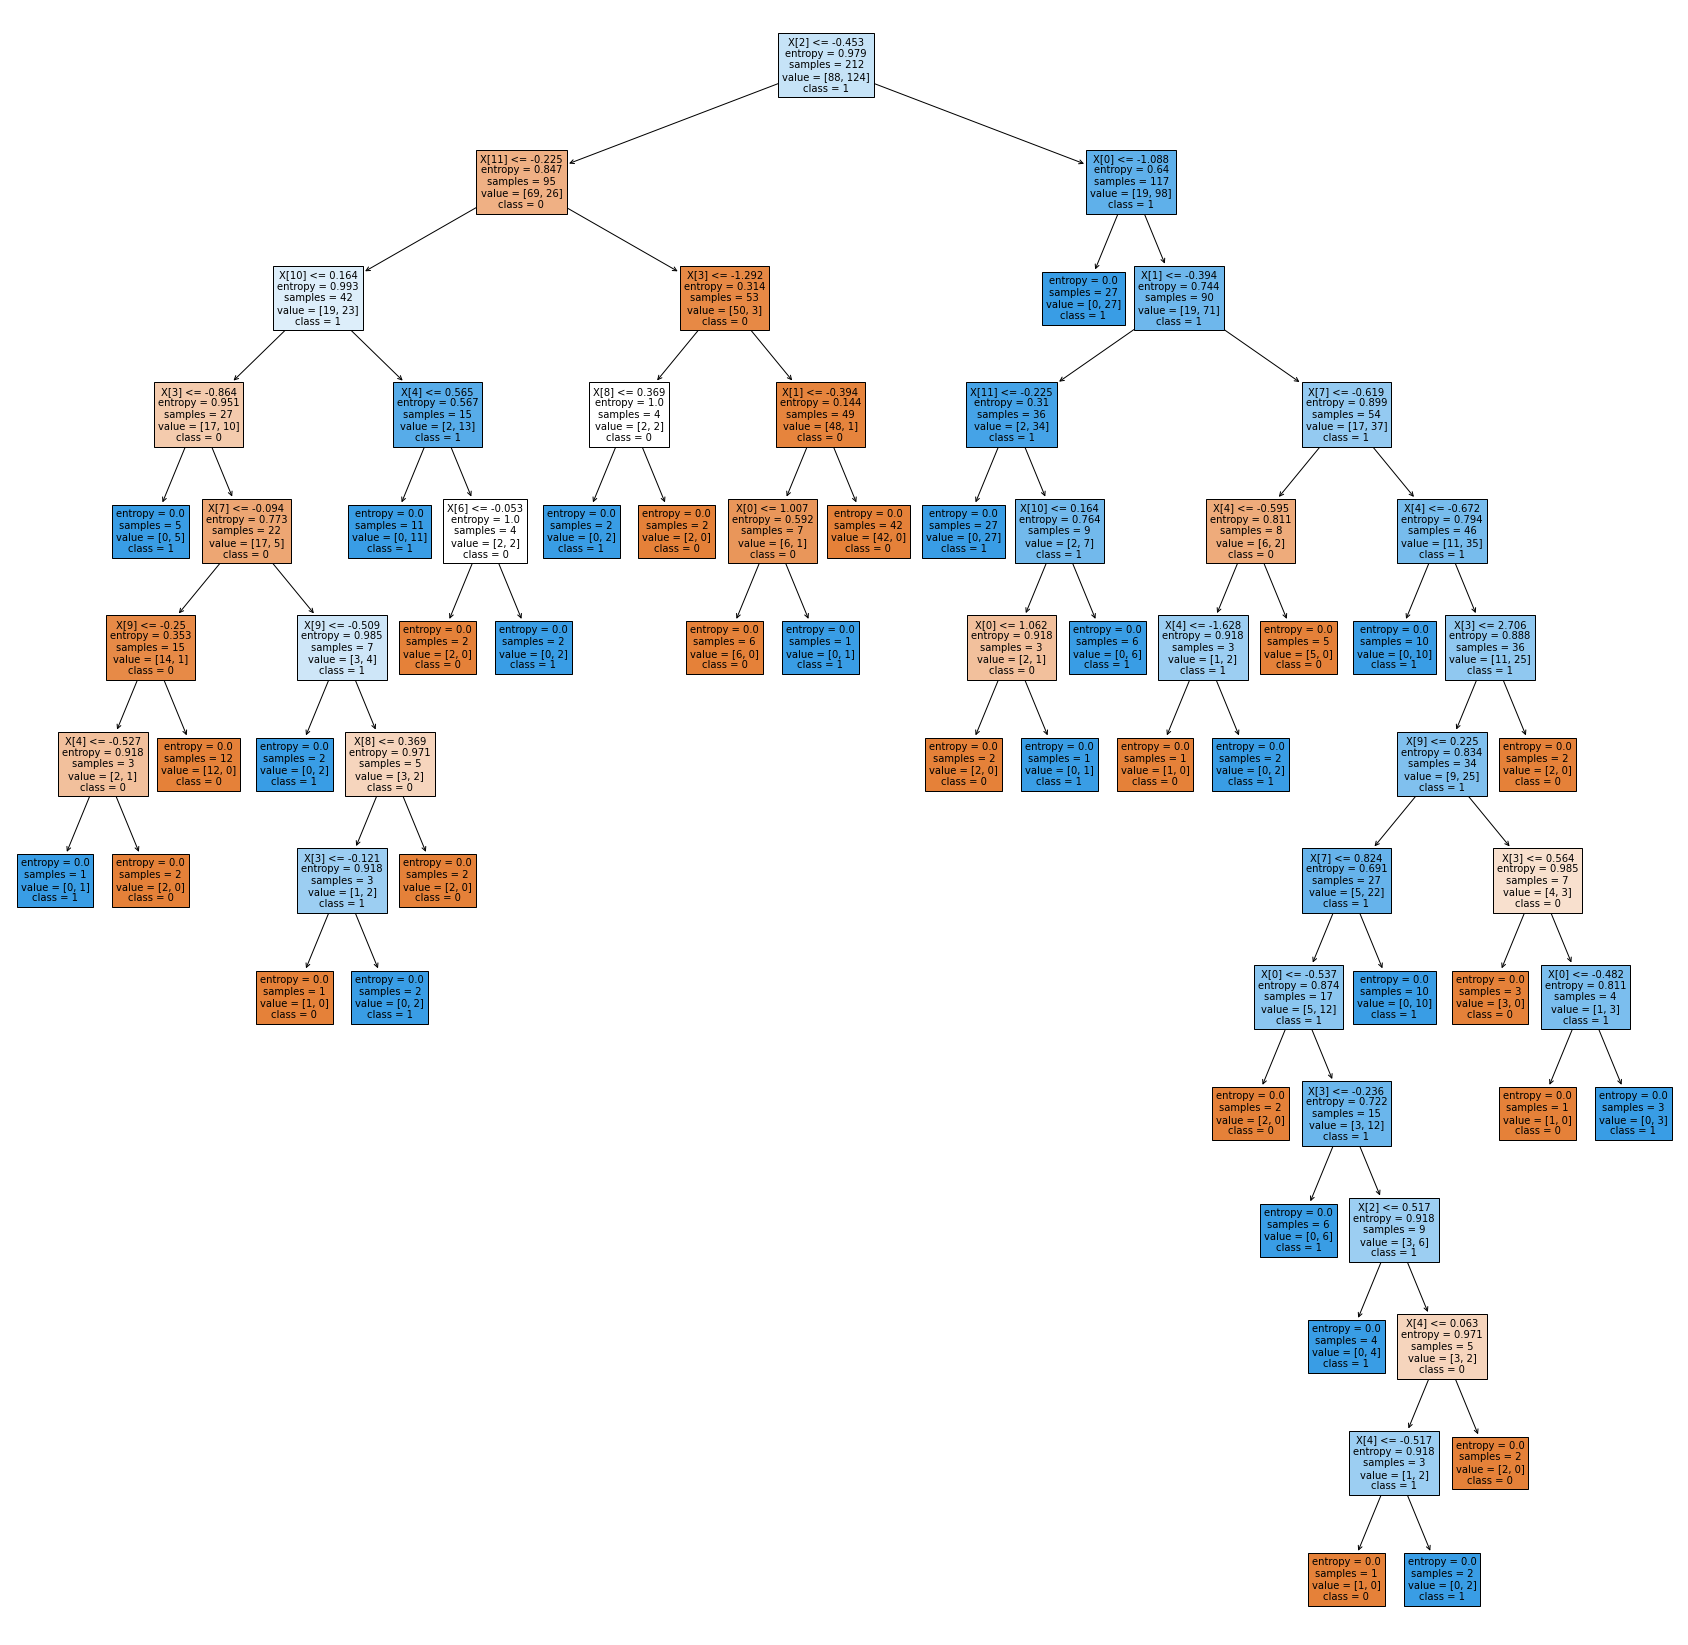

In [ ]:
# plot the decision tree 
fig = plt.figure(figsize=(30,30))
_ = tree.plot_tree(decision_tree_model,  
                   class_names=["0","1"],
                   filled=True)

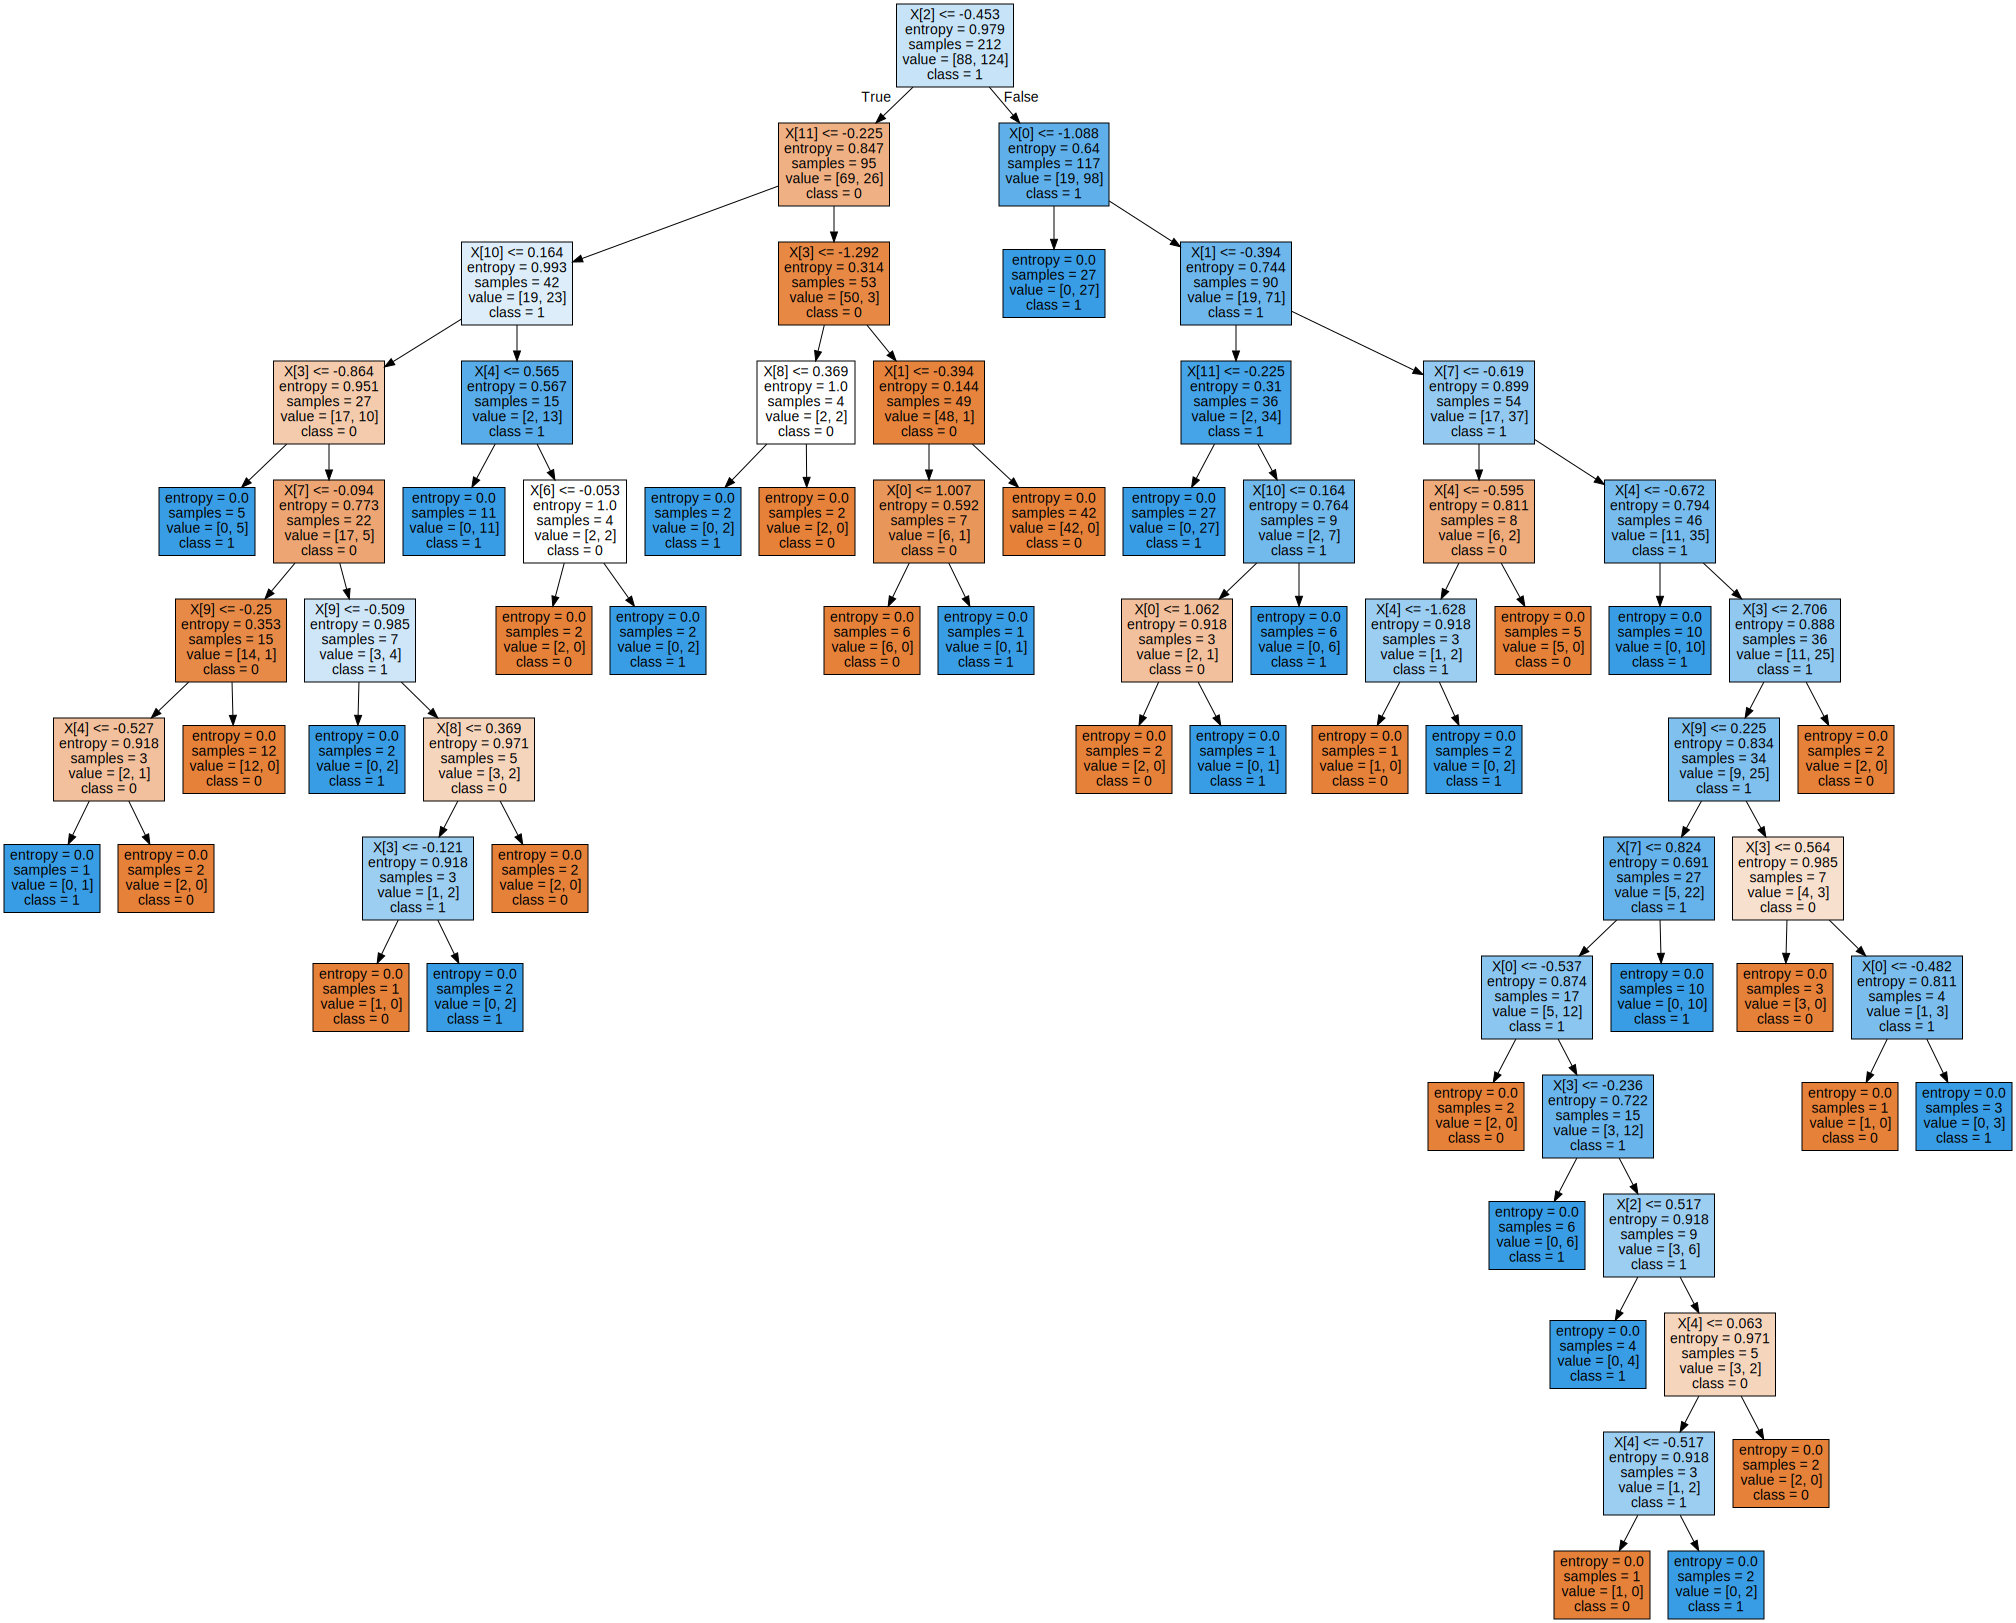

In [ ]:
# DOT data
dot_data = tree.export_graphviz(decision_tree_model, out_file=None, 
                                class_names=["0","1"],
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png") 
graph

#### Do predictions on the test set

In [ ]:
# predict probabilities on the test set
# consider the probability of positive class by subsetting with '[:,1]'
Y_pred_prob = decision_tree_model.predict_proba(X_test)[:,1]

In [ ]:
# predict the class labels using 'X_test'
Y_pred = decision_tree_model.predict(X_test)

#### Compute accuracy measures

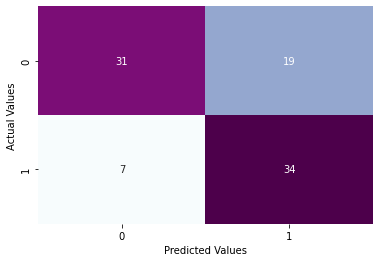

In [ ]:
# call the function to plot the confusion matrix.
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

In [ ]:
# compute the performance measures on test data
print("Classification report:")

print(classification_report(Y_test,Y_pred))

from sklearn.metrics import accuracy_score
acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.62      0.70        50
           1       0.64      0.83      0.72        41

    accuracy                           0.71        91
   macro avg       0.73      0.72      0.71        91
weighted avg       0.74      0.71      0.71        91

Accuracy of the model:  0.7142857142857143


**Interpretation**: The accuracy is 71% for this model. Also, the sensitivity and specificity of the model is quite different.

#### Create a generalized function to calculate the kappa score for the test set.

In [ ]:
# create a generalized function to calculate the metrics values for test set
def kappa_score(model):
    
    # return the kappa score on test set
    return(cohen_kappa_score(Y_test, Y_pred))

#### Define a function to plot the ROC curve.

In [ ]:
# define a function to plot the ROC curve and print the ROC-AUC score
def plot_roc(model):
    
    # the roc_curve() returns the values for false positive rate, true positive rate and threshold
    # pass the actual target values and predicted probabilities to the function
    fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob)

    # plot the ROC curve
    plt.plot(fpr, tpr)

    # set limits for x and y axes
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])

    # plot the straight line showing worst prediction for the model
    plt.plot([0, 1], [0, 1],'r--')

    # add plot and axes labels
    # set text size using 'fontsize'
    plt.title('ROC Curve for Heart Disease Classifier', fontsize = 15)
    plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
    plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
    # add the AUC score to the plot
    # 'x' and 'y' gives position of the text
    # 's' is the text 
    # use round() to round-off the AUC score upto 4 digits
    plt.text(x = 0.02, y = 0.9, s = ('AUC Score:',round(roc_auc_score(Y_test, Y_pred_prob),4)))

    # plot the grid
    plt.grid(True)

#### Create a generalized function to create a dataframe containing the scores for the models.

In [ ]:
# create an empty dataframe to store the scores for various classification algorithms
score_card = pd.DataFrame(columns=['Model', 'AUC Score', 'Precision Score', 'Recall Score', 'Accuracy Score',
                                   'Kappa Score', 'f1-score'])

# append the result table for all performance scores
# performance measures considered for comparision are 'AUC', 'Precision', 'Recall','Accuracy','Kappa Score', and 'f1-score'
# compile the required information in a user defined function 
def update_score_card(model_name):
    
    # assign 'score_card' as global variable
    global score_card

    # append the results to the dataframe 'score_card'
    # 'ignore_index = True' do not consider the index labels
    score_card = score_card.append({'Model': model_name,
                                    'AUC Score' : roc_auc_score(Y_test, Y_pred_prob),
                                    'Precision Score': metrics.precision_score(Y_test, Y_pred),
                                    'Recall Score': metrics.recall_score(Y_test, Y_pred),
                                    'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                                    'Kappa Score': cohen_kappa_score(Y_test, Y_pred),
                                    'f1-score': metrics.f1_score(Y_test, Y_pred)}, 
                                    ignore_index = True)
    return(score_card)

In [ ]:
# compute kappa score on test set
# call the function 'kappa_score'
# pass the decision tree model to the function
kappa_value = kappa_score(decision_tree_model)

# print the kappa value
print(kappa_value)

0.43773764258555137


**Interpretation**: As the kappa score for the decision tree is 0.4377, we can say that there is moderate agreement between the actual and predicted values.

#### Plot the ROC curve.

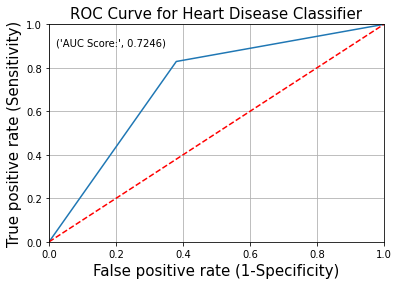

In [ ]:
# call the function 'plot_roc' to plot the ROC curve
# pass the decision tree model to the function
plot_roc(decision_tree_model)

The dotted line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).

We see our classifier (decision tree) to be away from the dotted line with the AUC score 0.7246.

#### Tabulate the results

In [ ]:
# use the function 'update_score_card' to store the performance measures
# pass the 'Decision Tree' as model name to the function
update_score_card(model_name = 'Decision Tree')

,Model,AUC Score,Precision Score,Recall Score,Accuracy Score,Kappa Score,f1-score
0,Decision Tree,0.724634,0.641509,0.829268,0.714286,0.437738,0.723404


### Prune a Decision Tree

Pruning reduces the size of the decision tree by removing the internal nodes of the tree. It decreases the complexity of the tree, and so improves the accuracy of prediction. It is useful because trees may fit the training data well, but may do a poor prediction on test data. A simpler tree often avoids over-fitting.


Now prune the decision tree, we start with our original data set gradually proceeding with our analysis

To prune a 'Decision Tree', we do the following:

1. Prune the decision tree
2. Plot the decision tree
3. Do predictions on the test set
4. Compute accuracy measures
5. Tabulate the results

#### 1. Prune the decision tree

We prune the decision tree by specifying the maximum depth and maximum number of leaves of the tree.

We use the unscaled features to build the tree.



In [ ]:
# instantiate the 'DecisionTreeClassifier' object
# max_depth: maximum depth of the tree 
# max_leaf_nodes: maximum number of leaf nodes in the tree
# pass the 'random_state' to obtain the same samples for each time you run the code
prune = DecisionTreeClassifier(max_depth = 5, max_leaf_nodes = 25 , random_state = 10)

# fit the model using fit() on train data
decision_tree_prune = prune.fit(X_train, Y_train)

#### 2. Plot the decision tree

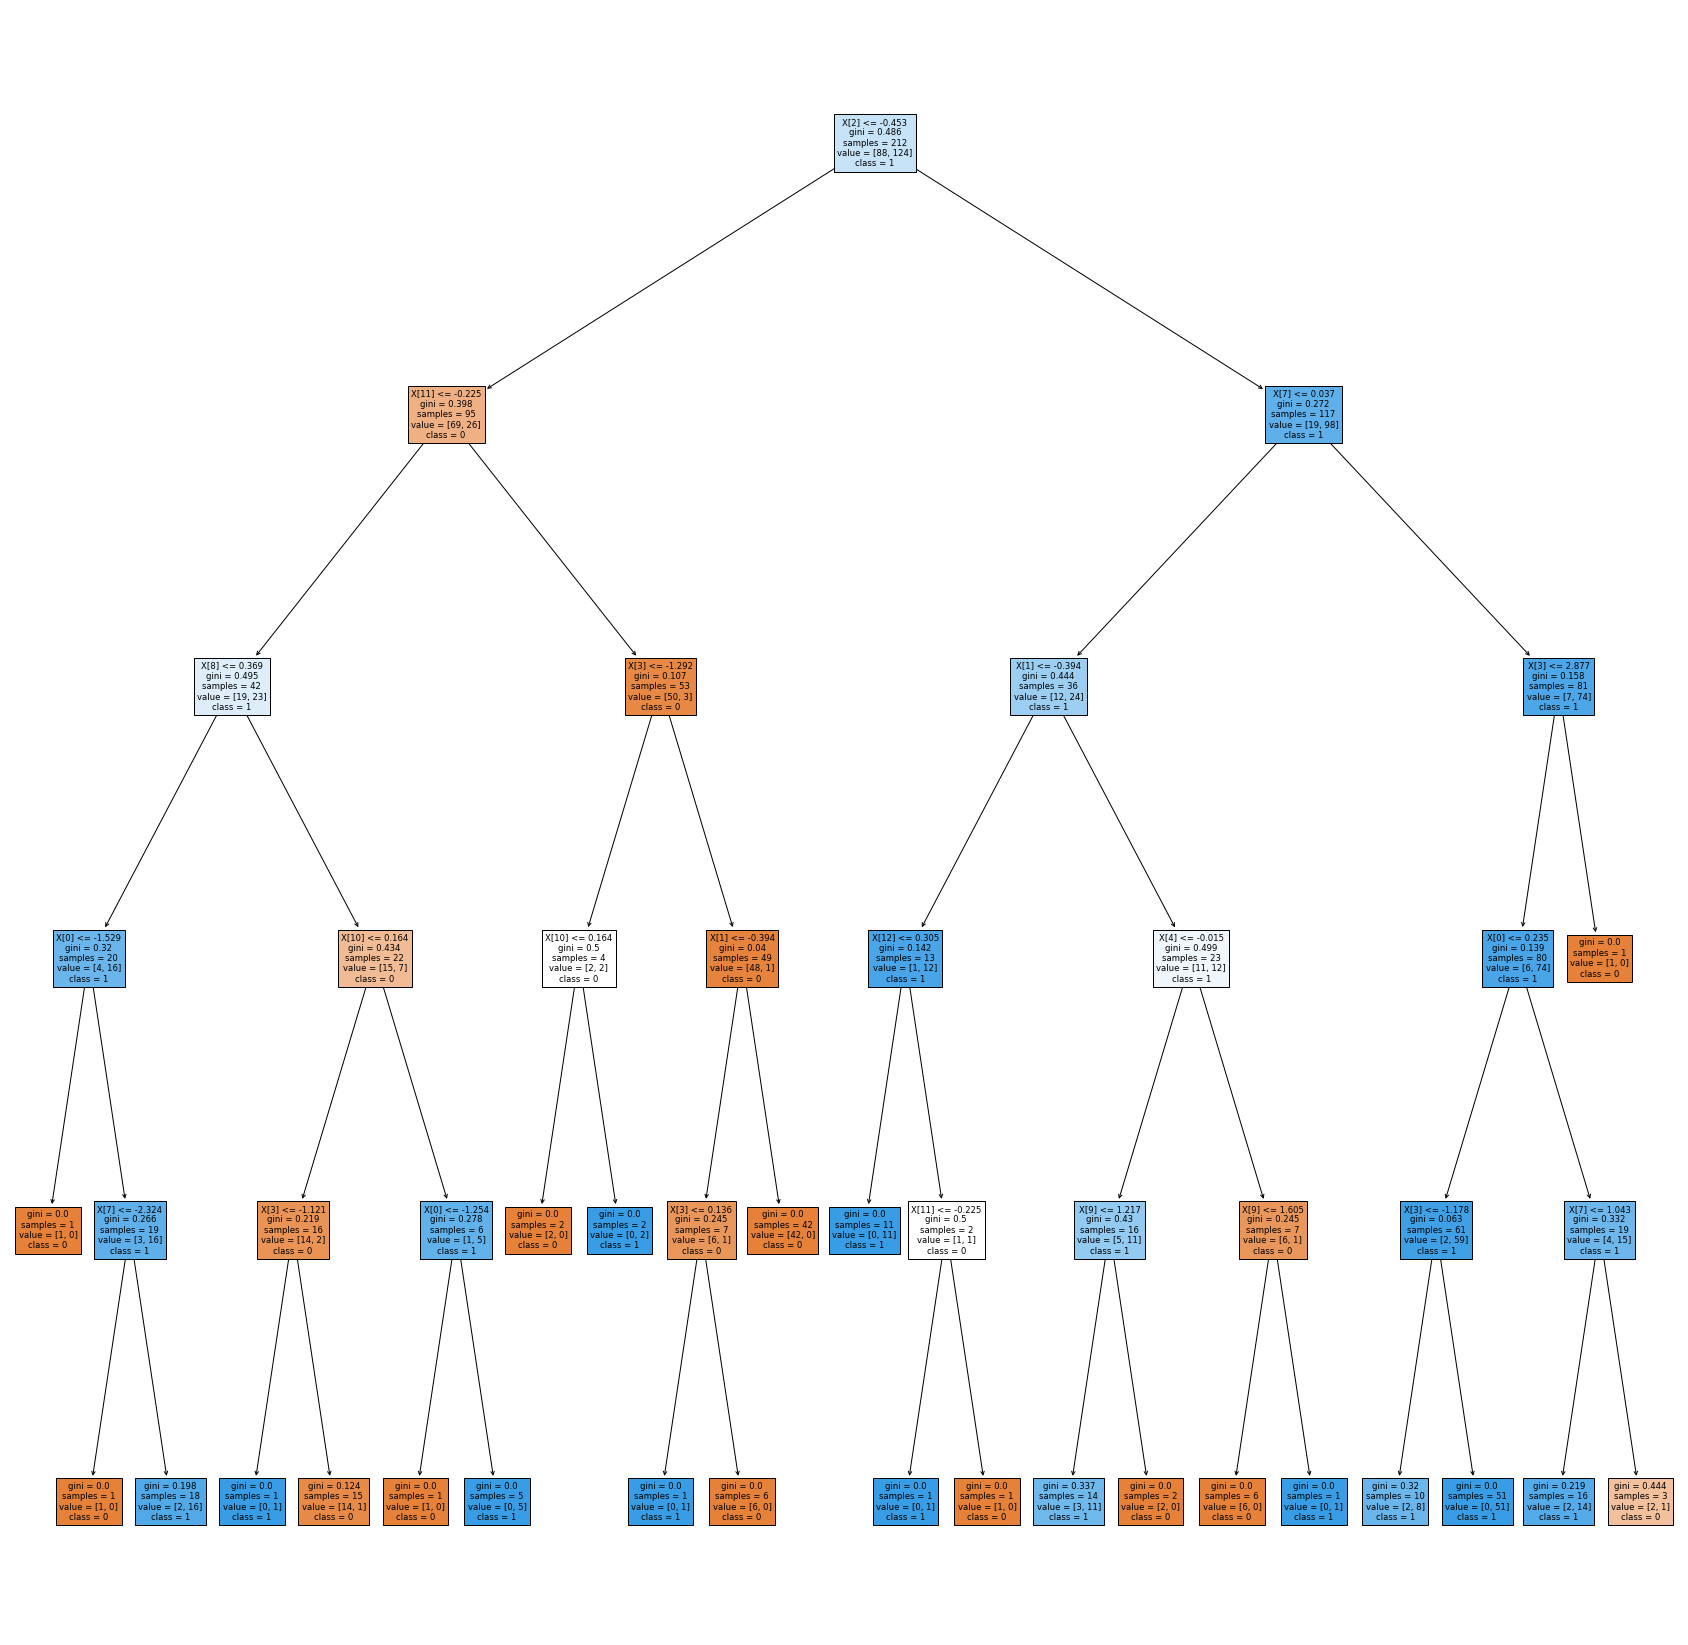

In [ ]:
# plot the decision tree 
fig = plt.figure(figsize=(30,30))
_ = tree.plot_tree(decision_tree_prune,   
                   class_names=["0","1"],
                   filled=True)

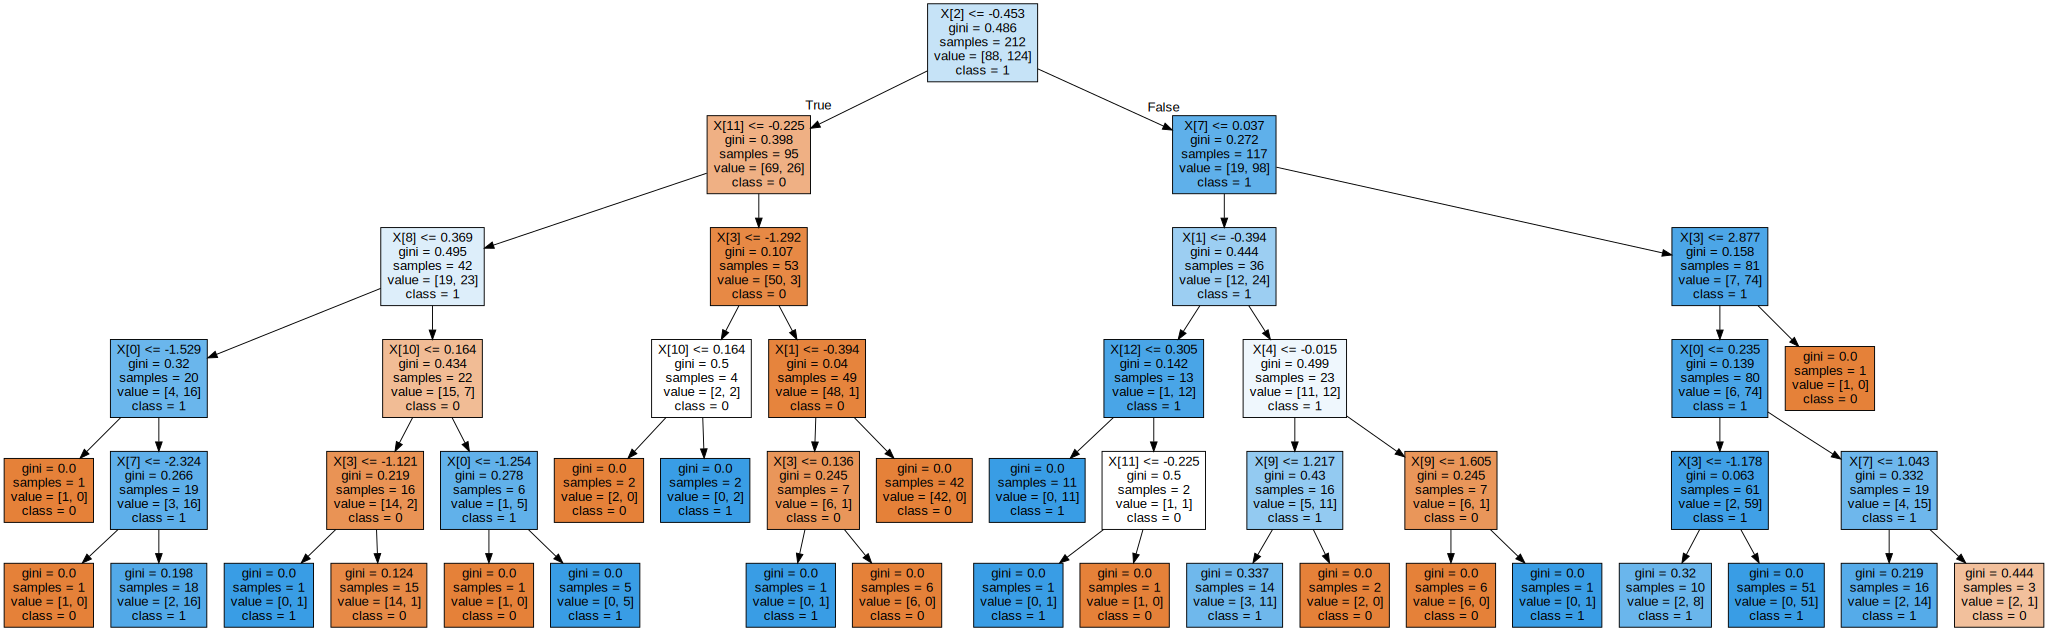

In [ ]:
# DOT data
dot_data = tree.export_graphviz(decision_tree_prune, out_file=None,
                                class_names=["0","1"],
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png") 
graph


#### 3. Do predictions on the test set



In [ ]:
# predict probabilities on the test set
# consider the probability of positive class by subsetting with '[:,1]'
Y_pred_prob = decision_tree_prune.predict_proba(X_test)[:,1]

In [ ]:
# predict the class labels using 'X_test'
Y_pred = decision_tree_prune.predict(X_test)

#### 4. Compute accuracy measures



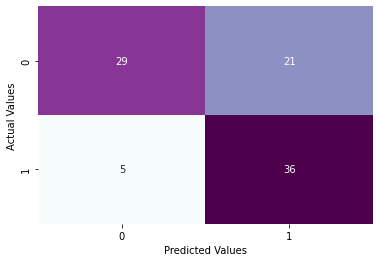

In [ ]:
# call the function to plot the confusion matrix.
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

In [ ]:
print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        50
           1       0.63      0.88      0.73        41

    accuracy                           0.71        91
   macro avg       0.74      0.73      0.71        91
weighted avg       0.75      0.71      0.71        91

Accuracy of the model:  0.7142857142857143


**Interpretation**: The accuracy is 71% for this model.

In [ ]:
# compute kappa score on test set
# call the function 'kappa_score'
# pass the decision tree (pruned) model to the function
kappa_value = kappa_score(decision_tree_prune)

# print the kappa value
print(kappa_value)

0.44250706880301605


**Interpretation**: As the kappa score for the decision tree (pruned) is 0.4425, we can say that there is moderate agreement between the actual and predicted values.

#### 4. Compute accuracy measures



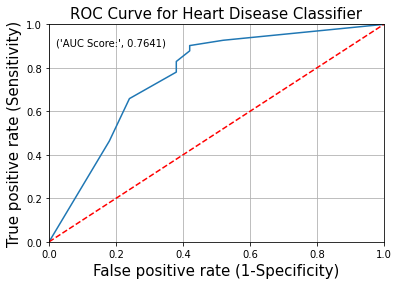

In [ ]:
# call the function 'plot_roc' to plot the ROC curve
# pass the decision tree (pruned) model to the function
plot_roc(decision_tree_prune)

The dotted line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).

We see our classifier (decision tree with pruning) to be away from the dotted line with the AUC score 0.7641.

#### 5. Tabulate the results

In [ ]:
# use the function 'update_score_card' to store the performance measures
# pass the 'Decision Tree (Pruned)' as model name to the function
update_score_card(model_name = 'Decision Tree (Pruned)')

,Model,AUC Score,Precision Score,Recall Score,Accuracy Score,Kappa Score,f1-score
0,Decision Tree,0.724634,0.641509,0.829268,0.714286,0.437738,0.723404
1,Decision Tree (Pruned),0.764146,0.631579,0.878049,0.714286,0.442507,0.734694


### Decision Tree (using GridSearchCV)


Now we show how a decision tree is optimized by cross-validation, which is done using the GridSearchCV() from sklearn library.

The performance of the selected hyperparameters and trained model is then measured on the test set that was not used during the model building.

Now we build a decision tree using the GridSearchCV. We start with our original data set gradually proceeding with our analysis

To build a Decision Tree using GridSearchCV, we do the following:
1. Use GridSearch to obtain the optimal values of hyperparameters
2. Build the model using the hyperparameters obtained in step 1
3. Plot the decision tree
4. Do predictions on the test set
5. Compute accuracy measures
6. Tabulate the results


#### 1. Use GridSearch to obtain the optimal values of hyperparameters

In [ ]:
# create a dictionary with hyperparameters and its values
# pass the criteria 'entropy' and 'gini' to the parameter, 'criterion' 
# pass the list of values to 'min_samples_split' that assigns minimum number of samples to split an internal node
# pass the list of values to 'max_depth' that assigns maximum depth of the tree
# pass the list of values to 'min_samples_leaf' that assigns minimum number of samples required at the terminal/leaf node
# pass the list of values to 'max_leaf_nodes' that assigns maximum number of leaf nodes in the tree
tuned_paramaters = [{'criterion': ['gini', 'entropy'],
                     'min_samples_split': [10, 20, 30],
                     'max_depth': [3, 5, 7, 9],
                     'min_samples_leaf': [15, 20, 25, 30, 35],
                     'max_leaf_nodes': [5, 10, 15, 20, 25]}]

In [ ]:
# instantiate the 'DecisionTreeClassifier' 
# pass the 'random_state' to obtain the same samples for each time you run the code
decision_tree_classification = DecisionTreeClassifier(random_state = 10)

# use GridSearchCV() to find the optimal value of the hyperparameters
# estimator: pass the decision tree classifier model
# param_grid: pass the list 'tuned_parameters'
# cv: number of folds in k-fold i.e. here cv = 10
grid = GridSearchCV(estimator = decision_tree_classification, 
                         param_grid = tuned_paramaters, 
                         cv = 10)

# fit the model on X_train and y_train using fit()
dt_grid = grid.fit(X_train, Y_train)

# get the best parameters
print('Best parameters for decision tree classifier: ', dt_grid.best_params_, '\n')

Best parameters for decision tree classifier:  {'criterion': 'gini', 'max_depth': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 15, 'min_samples_split': 10} 



#### 2. Build the model using the hyperparameters obtained in step 1

In [ ]:
# instantiate the 'DecisionTreeClassifier'
# 'best_params_' returns the dictionary containing best parameter values and parameter name  
# 'get()' returns the value of specified parameter
# pass the 'random_state' to obtain the same samples for each time you run the code
dt_grid_model = DecisionTreeClassifier(criterion = dt_grid.best_params_.get('criterion'),
                                       max_depth = dt_grid.best_params_.get('max_depth'),
                                       max_leaf_nodes = dt_grid.best_params_.get('max_leaf_nodes'),
                                       min_samples_leaf = dt_grid.best_params_.get('min_samples_leaf'),
                                       min_samples_split = dt_grid.best_params_.get('min_samples_split'),
                                       random_state = 10)

# use fit() to fit the model on the train set
dt_grid_model = dt_grid_model.fit(X_train, Y_train)

#### 3. Plot the decision tree

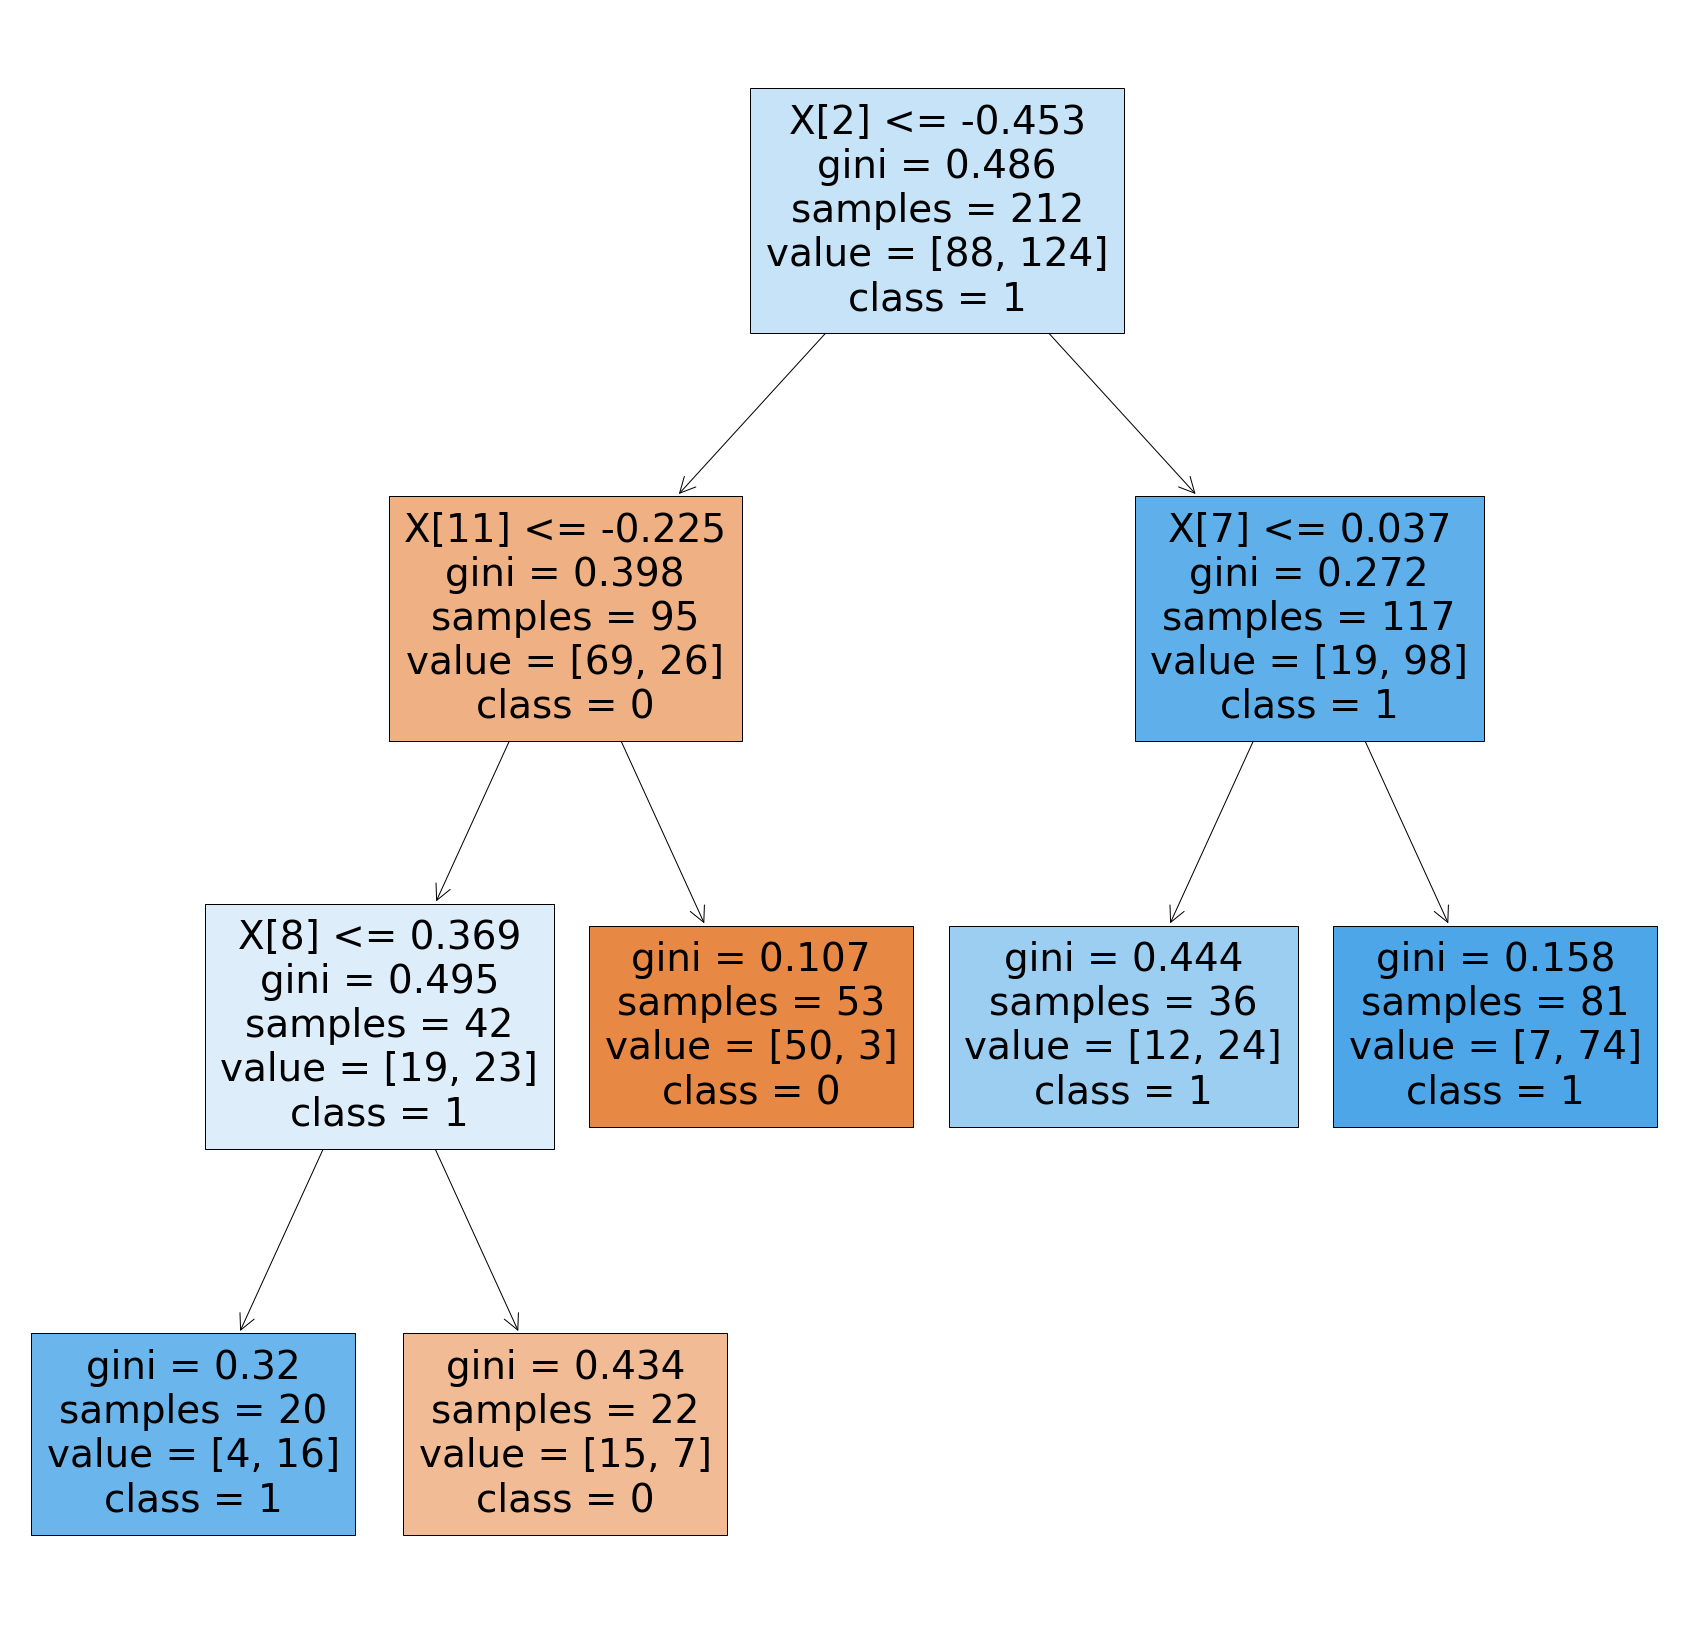

In [ ]:
# plot the decision tree 
fig = plt.figure(figsize=(30,30))
_ = tree.plot_tree(dt_grid_model, 
                   class_names=["0","1"],
                   filled=True)

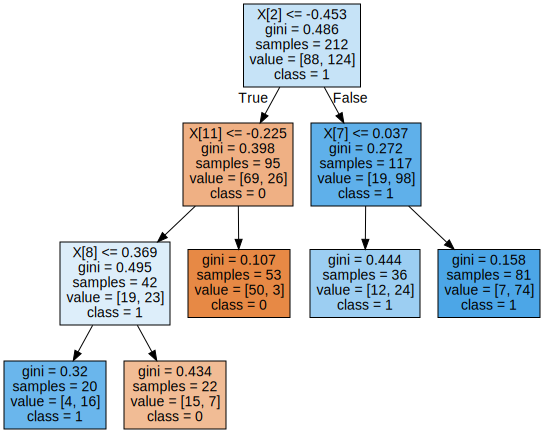

In [ ]:
# DOT data
dot_data = tree.export_graphviz(dt_grid_model, out_file=None,  
                                class_names=["0","1"],
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png") 
graph


#### 4. Do predictions on the test set

In [ ]:
# predict probabilities on the test set
# consider the probability of positive class by subsetting with '[:,1]'
Y_pred_prob = dt_grid_model.predict_proba(X_test)[:,1]

In [ ]:
# predict the class labels using 'X_test'
Y_pred = dt_grid_model.predict(X_test)

#### 5. Compute accuracy measures

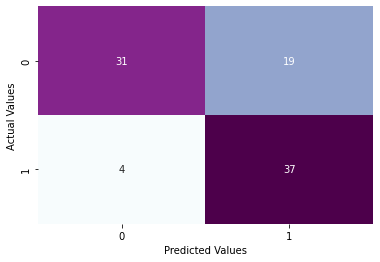

In [ ]:
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()


In [ ]:
print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.62      0.73        50
           1       0.66      0.90      0.76        41

    accuracy                           0.75        91
   macro avg       0.77      0.76      0.75        91
weighted avg       0.78      0.75      0.74        91

Accuracy of the model:  0.7472527472527473


**Interpretation**: The accuracy is 74.7% for this model.

In [ ]:
# compute kappa score on test set
# call the function 'kappa_score'
# pass the decision tree (GridSearchCV) model to the function
kappa_value = kappa_score(dt_grid_model)

# print the kappa value
print(kappa_value)

0.5057851239669422


**Interpretation**: As the kappa score for the decision tree (GridSearchCV) is 0.5057, we can say that there is moderate agreement between the actual and predicted values.

#### Plot the ROC curve.



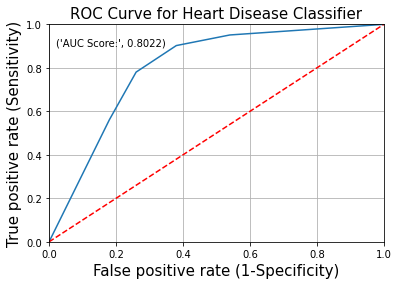

In [ ]:
# call the function 'plot_roc' to plot the ROC curve
# pass the decision tree (GridSearchCV) model to the function
plot_roc(dt_grid_model)

The dotted line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).

We see our classifier (decision tree with GridSearchCV) to be away from the dotted line with the AUC score 0.8022.

### Conclusion and Interpretation
To take the final conclusion, let us print the result table.

Tabulate the results

In [ ]:
# use the function 'update_score_card' to store the performance measures
# pass the 'Decision Tree (GridSearchCV)' as model name to the function
update_score_card(model_name = 'Decision Tree (GridSearchCV)')

,Model,AUC Score,Precision Score,Recall Score,Accuracy Score,Kappa Score,f1-score
0,Decision Tree,0.724634,0.641509,0.829268,0.714286,0.437738,0.723404
1,Decision Tree (Pruned),0.764146,0.631579,0.878049,0.714286,0.442507,0.734694
2,Decision Tree (GridSearchCV),0.802195,0.660714,0.902439,0.747253,0.505785,0.762887


The supervised classification learning algorithms named in the above table have been implemented on the given dataset. The performance of the models were evaluated using AUC score, accuracy, precision, f1-score, recall, and kappa score.

The above table shows that the Decision Tree (GridSearchCV) has the highest values for most of the performance measures like AUC Score, Recall, f1-score, accuracy. Therefore, it can be concluded that the Decision Tree (GridSearchCV) can be used to predict the existence of heart disease in the patients. In future when we have more observations or bigger dataset and we can also apply ensemble techniques for prediction that can be tested again.